# SkillLens AI — K-Means Clustering and Cluster Interpretation

**Stage 4 of the SkillLens AI project.**

This is the most important stage in the pipeline: it is where the `skill_category` target used by the classifier (Stage 5) gets created. It is **not** hand-written — it comes from inspecting how K-Means naturally groups students based on their 9 skill features, on the training data only.

**Rules followed in this notebook:**
- `generation_reference.csv` is **never** loaded.
- K-Means is fit **only** on `X_train_scaled`. `X_test_scaled` is only ever passed to `.predict()`, never `.fit()`.
- We do **not** force the data into 4 predefined categories. We look at what K-Means actually finds first, and only name clusters after inspecting their real characteristics.
- No classifier is trained and no accuracy is calculated in this notebook — that is Stage 5's job.
- The resulting `skill_category` labels are **pseudo-labels** derived from unsupervised clustering, not ground-truth outcomes observed in the real world. This is stated again at the end.

## 1. Import Libraries

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load Data and Recreate the Stage 3 Train/Test Split

We only load `student_data.csv` (never `generation_reference.csv`). Stage 3 did not save `X_train`/`X_test` to disk, so we recreate them here using the exact same feature list, `test_size=0.2`, and `random_state=42`. Because nothing about the data or the split logic has changed, this reproduces the identical split from Stage 3.

In [2]:
data = pd.read_csv("../data/raw/student_data.csv")

features = [
    "cgpa", "coding_skill", "dsa_skill", "math_aptitude", "communication_skill",
    "security_knowledge", "projects_count", "internships_count", "certifications_count",
]

X = data[features]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (240, 9)
X_test shape:  (60, 9)


## 3. Load the Stage 3 Scaler and Transform (Do Not Refit)

We load the scaler that was already fit on `X_train` in Stage 3 and use it only to `.transform()` — we never call `.fit()` on it here, and we never overwrite `scaler.pkl`.

In [3]:
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print("Loaded scaler from Stage 3 (not refit).")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)

Loaded scaler from Stage 3 (not refit).
X_train_scaled shape: (240, 9)
X_test_scaled shape:  (60, 9)


## 4. Explore k = 2 to 8 (Fit Only on X_train_scaled)

For each candidate number of clusters, we fit a K-Means model on the training data only and record two numbers:

- **Inertia**: how tightly packed the points are around their cluster center (lower = tighter clusters, but this always decreases as k increases, so it can't be used alone).
- **Silhouette score**: how well-separated the clusters are, from -1 (bad) to 1 (perfect). Unlike inertia, this can go up or down as k changes, which makes it more useful for choosing k.

In [4]:
k_values = [2, 3, 4, 5, 6, 7, 8]
inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans_trial = KMeans(n_clusters=k, random_state=42, n_init=10)
    trial_labels = kmeans_trial.fit_predict(X_train_scaled)

    inertia_scores.append(kmeans_trial.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, trial_labels))

k_search_results = pd.DataFrame({
    "k": k_values,
    "inertia": inertia_scores,
    "silhouette_score": silhouette_scores,
})
k_search_results

,k,inertia,silhouette_score
0,2,1395.285767,0.306848
1,3,1182.820593,0.224241
2,4,1039.635047,0.239130
3,5,953.884031,0.195130
4,6,907.804212,0.186831
5,7,873.667401,0.174763
6,8,834.153348,0.157867


## 5. Elbow Plot and Silhouette Plot

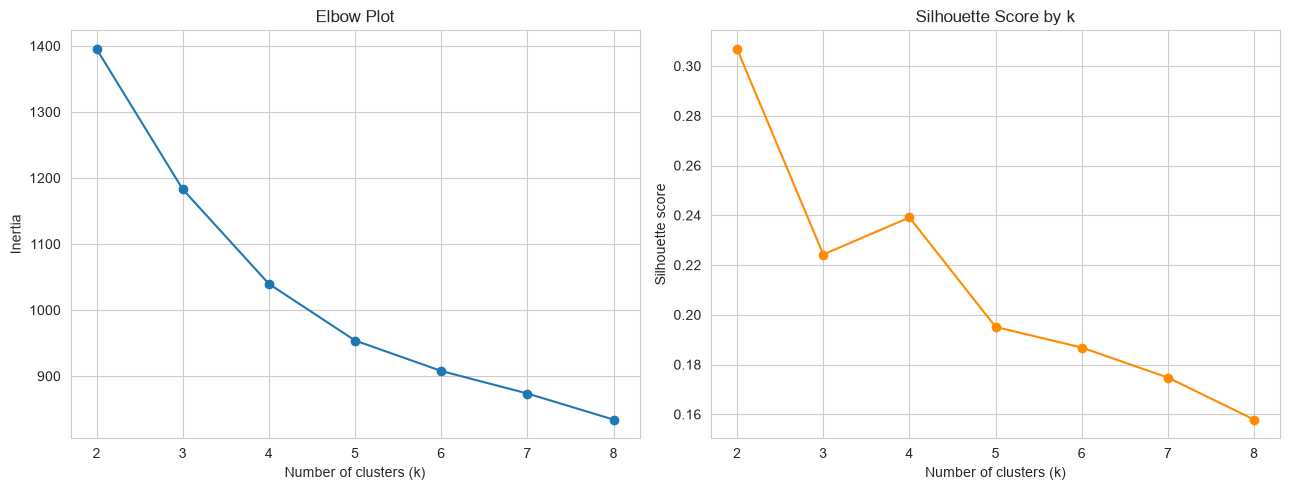

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_search_results["k"], k_search_results["inertia"], marker="o")
axes[0].set_title("Elbow Plot")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_search_results["k"], k_search_results["silhouette_score"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

**What the plots show:** Inertia decreases steadily as k increases (expected — it always does), with the rate of decrease slowing down noticeably after k=4. Silhouette score is highest at k=2 (≈0.31), drops at k=3 (≈0.22), then rises slightly again at k=4 (≈0.24) before steadily declining through k=5–8 (≈0.20 down to ≈0.16).

This means k=2 is the statistically "cleanest" split, but k=4 is a **local** high point — it scores better than both its neighbors, k=3 and k=5. We do not pick a k based on silhouette alone; we now look at what the actual clusters look like at a few candidate values (k=3, 4, 5) before deciding.

## 6. Inspect Cluster Sizes and Profiles for Candidate k Values

Before committing to a k, we check whether the resulting clusters are actually meaningfully different from each other, and whether they'd be interpretable as real student profiles. We look at k=3, k=4, and k=5, using the **original, unscaled** features so the numbers are easy to read.

In [6]:
for k in [3, 4, 5]:
    trial_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    trial_labels = trial_model.fit_predict(X_train_scaled)

    trial_profile = X_train.copy()
    trial_profile["cluster"] = trial_labels

    print(f"===== k = {k} =====")
    print("Cluster sizes:")
    print(trial_profile["cluster"].value_counts().sort_index())
    print()
    print("Cluster means (original, unscaled features):")
    print(trial_profile.groupby("cluster")[features].mean().round(2))
    print()

===== k = 3 =====
Cluster sizes:
cluster
0    100
1     78
2     62
Name: count, dtype: int64

Cluster means (original, unscaled features):
         cgpa  coding_skill  dsa_skill  math_aptitude  communication_skill  \
cluster                                                                      
0        6.89          7.22       6.99           6.51                 4.52   
1        6.10          4.28       3.71           4.52                 4.96   
2        8.36          8.46       8.00           8.00                 7.50   

         security_knowledge  projects_count  internships_count  \
cluster                                                          
0                      6.87            4.61               1.28   
1                      3.66            1.88               0.68   
2                      6.25            5.94               1.52   

         certifications_count  
cluster                        
0                        2.44  
1                        0.58  
2         

## 7. Final Decision on k

**k=3** produces one large, fairly generic "everyone in the middle" group alongside a weak group and a strong group — it doesn't separate the two genuinely different kinds of "strong" student we can see emerging at k=4 (technically strong vs. strong-and-well-rounded).

**k=5** splits one of the k=4 groups into two smaller, less distinct pieces without materially improving cluster separation (silhouette drops from ≈0.24 to ≈0.20), so the extra group doesn't earn its complexity.

**k=4** is our choice, for two combined reasons:

1. **Quantitative:** k=4's silhouette score (≈0.239) is a local peak — higher than both k=3 (≈0.224) and k=5 (≈0.195) — and the elbow plot shows inertia's rate of improvement clearly slowing down around k=4. It is *not* the highest silhouette overall (k=2 is, at ≈0.307), so we are not claiming k=4 is mathematically optimal — it isn't, by that one metric alone.
2. **Practical/interpretability:** k=2 only separates "stronger" from "weaker" students, which is too coarse to be useful for the product — it wouldn't give students actionable categories. k=4 produces four genuinely distinct, explainable groups (shown next), which is what a skill-category feature for this product actually needs.

This combination — a locally strong (though not globally best) silhouette score, plus a real interpretability need — is why k=4 is chosen, not because the metrics alone point to it.

## 8. Fit the Final K-Means Model (k = 4, Training Data Only)

Parameters explained simply:
- `n_clusters=4`: the number of groups we decided on above.
- `random_state=42`: makes the result reproducible — K-Means starts from random initial cluster centers, and fixing this seed means we get the same result every time we run this notebook.
- `n_init=10`: K-Means is run 10 times with different random starting points, and the best result (lowest inertia) is kept. This avoids getting unlucky with a bad random start.

This model is fit **only** on `X_train_scaled`.

In [7]:
final_k = 4

kmeans_model = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_model.fit(X_train_scaled)

print(f"K-Means fitted with k={final_k} on X_train_scaled only.")

K-Means fitted with k=4 on X_train_scaled only.


## 9. Cluster Assignments for Train and Test

Training cluster labels come from the model we just fit (`.labels_`, the assignments made during fitting). Test cluster labels come **only** from calling `.predict()` on the already-fitted model — K-Means is never fit again on the test data.

In [8]:
train_cluster_ids = kmeans_model.labels_
test_cluster_ids = kmeans_model.predict(X_test_scaled)  # predict only - never fit on test data

print("Train cluster assignment counts:")
print(pd.Series(train_cluster_ids).value_counts().sort_index())
print()
print("Test cluster assignment counts:")
print(pd.Series(test_cluster_ids).value_counts().sort_index())

Train cluster assignment counts:
0    81
1    54
2    49
3    56
Name: count, dtype: int64

Test cluster assignment counts:
0    21
1    13
2    10
3    16
Name: count, dtype: int64


## 10. Cluster Profile Table (Original, Unscaled Features)

This is the key interpretation table. It uses the **original** feature values (not the standardized ones) so the numbers are directly meaningful — e.g. "average CGPA 8.4" is easy to reason about, "average CGPA 1.2 standard deviations above the mean" is not.

In [9]:
train_profile = X_train.copy()
train_profile["cluster"] = train_cluster_ids

cluster_sizes = train_profile["cluster"].value_counts().sort_index()
cluster_sizes.name = "num_students"

cluster_means = train_profile.groupby("cluster")[features].mean().round(2)

cluster_profile_table = cluster_means.copy()
cluster_profile_table.insert(0, "num_students", cluster_sizes)
cluster_profile_table

,num_students,cgpa,coding_skill,dsa_skill,math_aptitude,communication_skill,security_knowledge,projects_count,internships_count,certifications_count
cluster,,,,,,,,,,
0,81,6.17,4.33,3.79,4.56,4.94,3.68,1.93,0.68,0.63
1,54,6.97,8.18,8.39,7.41,4.24,5.56,5.33,1.13,1.89
2,49,6.83,6.36,5.71,5.75,4.98,8.34,4.04,1.45,3.10
3,56,8.43,8.49,7.94,8.02,7.70,6.30,5.96,1.57,3.20


## 11. Interpreting Each Cluster

Reading directly off the table above (cluster numbers are arbitrary IDs K-Means assigned — they carry no inherent order or meaning):

- **Cluster 0 (81 students)** — lowest average on **every single feature**: cgpa 6.17, coding 4.33, dsa 3.79, math 4.56, communication 4.94, security 3.68, projects 1.93, internships 0.68, certifications 0.63. A clean, unambiguous "weakest across the board" profile.
- **Cluster 1 (54 students)** — high coding (8.18), the *highest* DSA (8.39) and strong math (7.41) and projects (5.33), but the **lowest communication of all four clusters** (4.24). This is a textbook technically-strong-but-weaker-soft-skills profile.
- **Cluster 2 (49 students)** — its standout trait is security knowledge at 8.34, clearly higher than any other cluster (next-highest is 6.30). Everything else sits in the middle of the pack: cgpa, coding, dsa, and math are all 3rd-highest of the 4 clusters, while communication, projects, internships, and certifications are 2nd-highest. Not the strongest, not the weakest — moderate overall, with one specific specialization.
- **Cluster 3 (56 students)** — the highest average on 7 of the 9 features (cgpa 8.43, coding 8.49, math 8.02, communication 7.70, projects 5.96, internships 1.57, certifications 3.20), and 2nd-highest on the remaining two (dsa 7.94, security 6.30). This is a genuinely strong, well-rounded, high-achieving profile — not a "moderate/average" one.

**Honest note on naming:** the product's originally suggested category set was *Strong Technical, Balanced, Developing, Needs Improvement*. Clusters 0 and 1 map cleanly onto "Needs Improvement" and "Strong Technical." Cluster 3, however, is **not** a moderate/balanced group — it is the strongest group overall, so labeling it "Balanced" would misrepresent it. We instead name it **"Strong Overall"**, and reserve **"Balanced"** for Cluster 2, which genuinely does sit in the middle for most features (with one specialization). This is a deliberate deviation from forcing the data into the four originally-proposed names, per the instruction not to force predefined categories onto the clusters.

## 12. Cluster ID → Skill Category Mapping

**This mapping is written only now, after inspecting the cluster profiles above — not before.**

**Important limitation, stated explicitly:** these category names are *pseudo-labels*. They come from an unsupervised algorithm grouping students by similarity, followed by our own human interpretation of what each group's average profile looks like. They are **not** ground-truth outcomes observed in the real world (e.g., not verified by actual hiring outcomes, mentor ratings, or job performance). A different, equally reasonable person might draw the group boundaries slightly differently or choose different names. Stage 5's classifier will learn to reproduce these pseudo-labels, not to predict a real, independently observed fact.

In [10]:
cluster_to_category = {
    0: "Needs Improvement",
    1: "Strong Technical",
    2: "Balanced",
    3: "Strong Overall",
}

print("Cluster ID -> Skill Category mapping:")
for cluster_id, category_name in cluster_to_category.items():
    print(f"  {cluster_id} -> {category_name}")

Cluster ID -> Skill Category mapping:
  0 -> Needs Improvement
  1 -> Strong Technical
  2 -> Balanced
  3 -> Strong Overall


## 13. Create the `skill_category` Target

For the training data, we map each student's cluster ID (from fitting K-Means) to its category name. For the test data, we map each student's cluster ID from **`.predict()`** (never re-fit) to the same mapping.

In [11]:
y_train_skill_category = pd.Series(train_cluster_ids, index=X_train.index).map(cluster_to_category)
y_test_skill_category = pd.Series(test_cluster_ids, index=X_test.index).map(cluster_to_category)

print("Training skill_category counts:")
print(y_train_skill_category.value_counts())
print()
print("Testing skill_category counts:")
print(y_test_skill_category.value_counts())

Training skill_category counts:
Needs Improvement    81
Strong Overall       56
Strong Technical     54
Balanced             49
Name: count, dtype: int64

Testing skill_category counts:
Needs Improvement    21
Strong Overall       16
Strong Technical     13
Balanced             10
Name: count, dtype: int64


## 14. Save the Fitted K-Means Model and the Category Mapping

We save the fitted K-Means model and the cluster-to-category mapping so Stage 5 (classification) can reuse them without refitting. `scaler.pkl` from Stage 3 is not touched or overwritten.

In [12]:
joblib.dump(kmeans_model, "../models/kmeans_model.pkl")

# JSON keys must be strings, so we convert the cluster IDs when saving.
cluster_to_category_json = {str(cluster_id): name for cluster_id, name in cluster_to_category.items()}
with open("../models/cluster_category_mapping.json", "w") as f:
    json.dump(cluster_to_category_json, f, indent=2)

print("Saved ml/models/kmeans_model.pkl")
print("Saved ml/models/cluster_category_mapping.json")

Saved ml/models/kmeans_model.pkl
Saved ml/models/cluster_category_mapping.json


## 15. Leakage Check

A final check on the rules this notebook was required to follow:

- **`generation_reference.csv` was never loaded.** Only `pd.read_csv("../data/raw/student_data.csv")` appears anywhere in this notebook (Section 2). No other CSV is read.
- **K-Means was fitted only on training data.** The only `.fit()` / `.fit_predict()` calls on any K-Means model in this notebook (the k-search loop, the k=3/4/5 profile check, and the final model) are all called on `X_train_scaled`. `X_test_scaled` never appears as an argument to `.fit()` anywhere.
- **Test data was only passed to `.predict()`.** `X_test_scaled` is used exactly once for clustering purposes, in Section 9: `kmeans_model.predict(X_test_scaled)`.
- **No classifier was trained, and no classification accuracy was calculated.** This notebook only contains K-Means clustering code — no `LogisticRegression`, `KNeighborsClassifier`, `SVC`, `DecisionTreeClassifier`, `RandomForestClassifier`, or accuracy/precision/recall/F1 computation appears anywhere.

All four checks pass.

## Clustering Conclusion

**k values tested:** 2 through 8, using inertia and silhouette score, evaluated only on `X_train_scaled`.

**What elbow/silhouette showed:** silhouette peaked at k=2 (≈0.31, the global maximum), dropped at k=3 (≈0.22), rose again slightly at k=4 (≈0.24, a local peak above both neighbors), then declined steadily through k=5–8. The elbow plot's rate of improvement visibly slows after k=4.

**Why k=4 was selected:** not because it was the single best silhouette score — it wasn't (k=2 was higher). It was chosen because it is a genuine local peak in silhouette score (better than k=3 and k=5), the elbow plot supports it as a reasonable stopping point, and — critically — it produces four clusters that are actually distinguishable from each other in the original feature space, unlike k=2 which would only separate "stronger" from "weaker" students and give the product nothing actionable to work with.

**What each cluster represents** (from inspecting original, unscaled feature means):
- Cluster 0 → weakest across every feature → **Needs Improvement**
- Cluster 1 → strong coding/DSA/math/projects, weakest communication → **Strong Technical**
- Cluster 2 → moderate on most features, standout security knowledge → **Balanced**
- Cluster 3 → highest on almost every feature → **Strong Overall**

**How cluster labels became skill categories:** the four clusters were inspected first, using only their real, original-scale feature means — no names were decided in advance. The `cluster_to_category` mapping was written only after this inspection, and Cluster 3 was deliberately named "Strong Overall" instead of the originally-proposed "Balanced," because its actual profile (highest on 7 of 9 features) does not match what "balanced" means.

**Why these categories are pseudo-labels, not ground truth:** they were produced by an unsupervised algorithm grouping students by feature similarity, followed by human interpretation of the resulting groups' averages. No independent, real-world measurement (e.g. actual job placement, mentor assessment, or employer feedback) was used to define or validate these categories. Stage 5's classifier will therefore be learning to reproduce K-Means's discovered groupings for new students — a useful and legitimate technique (avoids re-running K-Means for every new student) — but its accuracy describes how well it reproduces *these clusters*, not how well it predicts real-world career readiness or success. This must not be misrepresented in the final report or the app itself.

No target/label existed before this notebook. No classifier was trained here. Stage 5 will use `X_train_scaled` / `X_test_scaled` and this notebook's `skill_category` labels to train and compare the 5 classifiers.